**SHARPENING AND BRIGHTENING**

Masukkan nilai brightness (misal 50 untuk lebih terang, -50 untuk lebih gelap): 


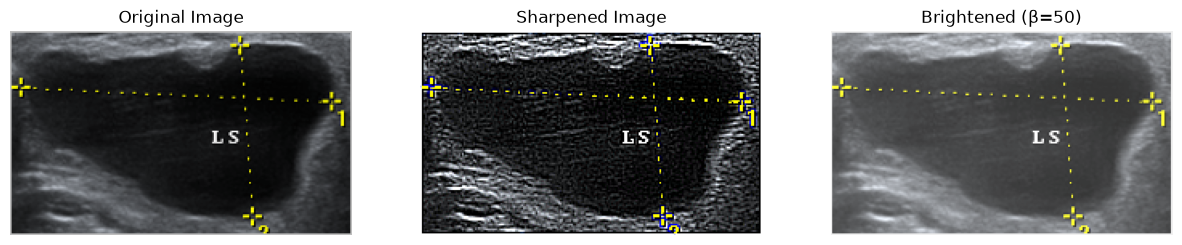

In [6]:
# --- Import Library ---
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "Contoh 2.png"

# Baca gambar
img = cv2.imread(img_path)
# Konversi ke RGB (karena OpenCV default BGR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Sharpening ---
# Kernel sharpening sederhana
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])
sharpened = cv2.filter2D(img_rgb, -1, kernel_sharpening)

# --- Brightening ---
print("Masukkan nilai brightness (misal 50 untuk lebih terang, -50 untuk lebih gelap): ")
brightness_value = 50

brightened = cv2.convertScaleAbs(img_rgb, alpha=1, beta=brightness_value)

# --- Tampilkan Hasil ---
plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(brightened)
plt.title(f"Brightened (β={brightness_value})")
plt.axis("off")

plt.show()


**FILTERING**

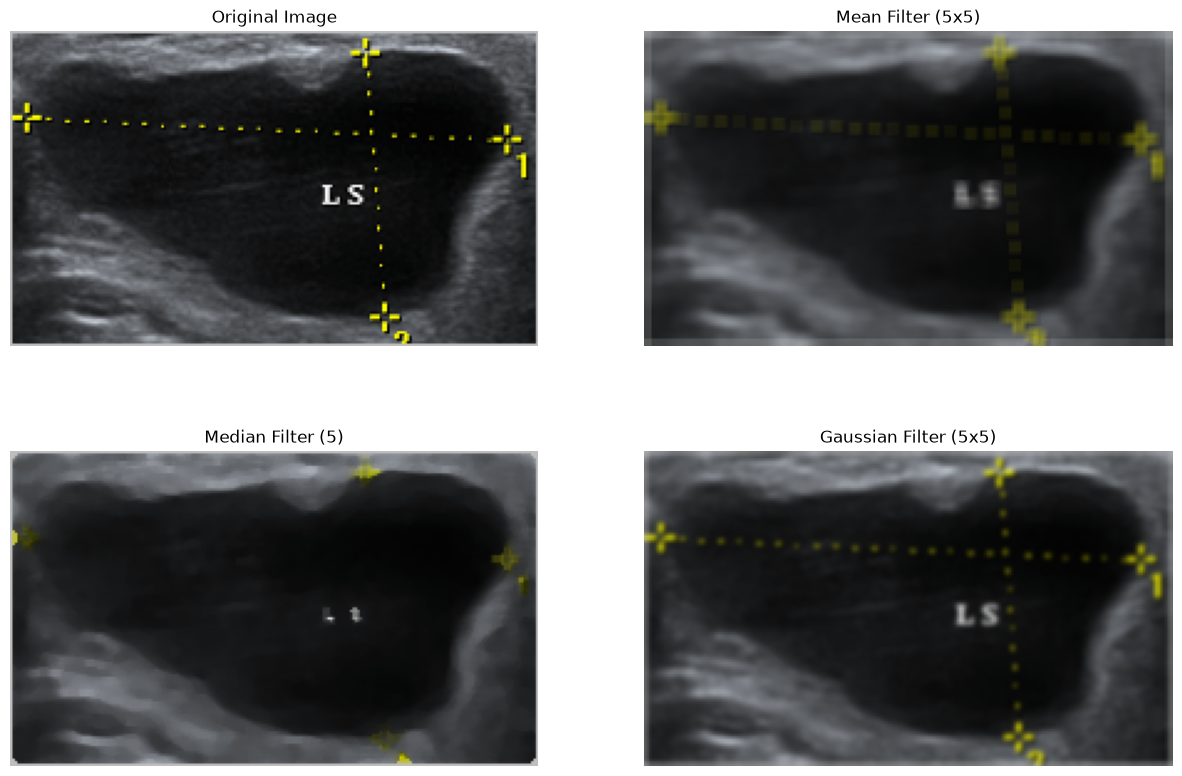

In [1]:
# --- Install & Import Library ---
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "Contoh 2.png"

# Baca gambar
img = cv2.imread(img_path)
# Konversi ke RGB (karena OpenCV default BGR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Filtering ---

# 1. Mean Filter (Average Blur)
mean_filter = cv2.blur(img_rgb, (5,5))  # kernel 5x5

# 2. Median Filter
median_filter = cv2.medianBlur(img_rgb, 5)  # kernel 5

# 3. Gaussian Filter
gaussian_filter = cv2.GaussianBlur(img_rgb, (5,5), 0)

# --- Tampilkan Hasil ---
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mean_filter)
plt.title("Mean Filter (5x5)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(median_filter)
plt.title("Median Filter (5)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(gaussian_filter)
plt.title("Gaussian Filter (5x5)")
plt.axis("off")

plt.show()


**ADAPTIVE MEDIAN FILTERING**

/tmp/ipykernel_7520/1131296582.py:33: RuntimeWarning: overflow encountered in scalar subtract
  B2 = Zxy - Zmax


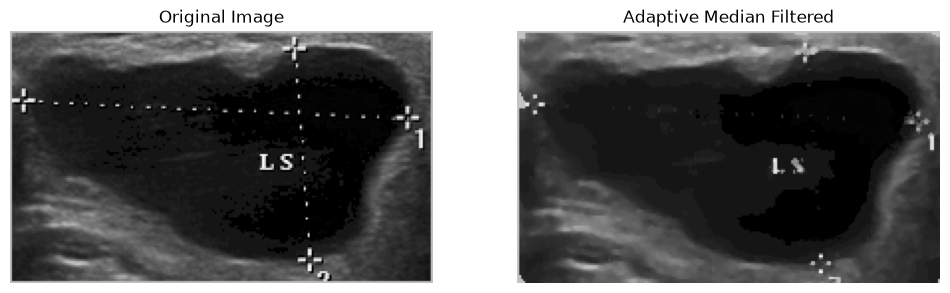

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "Contoh 2.png"

# Baca gambar grayscale
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# --- Adaptive Median Filter ---
def adaptive_median_filter(image, max_kernel_size=7):
    padded_img = np.pad(image, max_kernel_size//2, mode='edge')
    output = np.zeros_like(image)

    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            k = 3  # mulai dari kernel 3x3
            pixel_processed = False

            while k <= max_kernel_size and not pixel_processed:
                window = padded_img[i:i+k, j:j+k].flatten()
                Zmin = np.min(window)
                Zmax = np.max(window)
                Zmed = np.median(window)
                Zxy = padded_img[i + k//2, j + k//2]

                A1 = Zmed - Zmin
                A2 = Zmed - Zmax

                if A1 > 0 and A2 < 0:
                    B1 = Zxy - Zmin
                    B2 = Zxy - Zmax
                    if B1 > 0 and B2 < 0:
                        output[i, j] = Zxy
                    else:
                        output[i, j] = Zmed
                    pixel_processed = True
                else:
                    k += 2  # perbesar kernel ukuran ganjil berikutnya

            if not pixel_processed:
                output[i, j] = Zmed  # fallback
    return output

# Terapkan filter
filtered_img = adaptive_median_filter(img, max_kernel_size=7)

# --- Tampilkan Hasil ---
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filtered_img, cmap='gray')
plt.title("Adaptive Median Filtered")
plt.axis("off")

plt.show()


**BILATERAL FILTERING**

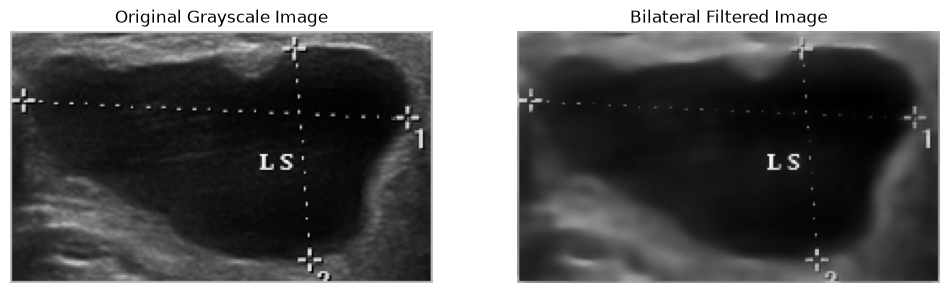

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

filename = "Contoh 2.png"

image = cv2.imread(filename)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

bilateral = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bilateral, cmap='gray')
plt.title("Bilateral Filtered Image")
plt.axis("off")

plt.show()
